In [2]:
import pandas as pd

df = pd.read_csv("../data/british_airways_reviews 2.csv")

df.head()

,Unnamed: 0,title,reviews
0,0,"""unprofessional attitude of the pilots""",BA 246 21JAN 2023 Did not appreciate the unp...
1,1,“Next time it will be Jet2”,Not a great experience. I could not check in ...
2,2,“become the Ryanair of long-haul travel”,I was excited to fly BA as I'd not travelled ...
3,3,“They never help us”,I just want to warn everyone of the worst cu...
4,4,“uncomfortable seat and disgusting food”,Paid for business class travelling Cairo to L...


In [3]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1300, 3)


In [4]:
df.isnull().sum()

Unnamed: 0    0
title         0
reviews       0
dtype: int64

In [6]:
df["reviews"].sample(5)


1166     Flew London Gatwick to Tirana Rinas. Bag drop...
938       London City to Zurich, I fly this route a lo...
767      Amman to London. This is a nice aircraft, wit...
1110      Johannesburg to London. I tend to stay with ...
281       A rather empty and quiet flight to Tel Aviv,...
Name: reviews, dtype: str

In [7]:
df["review_length"] = df["reviews"].str.len()

df["review_length"].describe()

count    1300.000000
mean      827.796923
std       568.608582
min       131.000000
25%       428.750000
50%       682.500000
75%      1047.250000
max      3491.000000
Name: review_length, dtype: float64

In [8]:
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/codespace/nltk_data...


True

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

sample_review = df["reviews"][0]

sia.polarity_scores(sample_review)

{'neg': 0.061, 'neu': 0.869, 'pos': 0.07, 'compound': 0.5013}

In [10]:
df["sentiment_score"] = df["reviews"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

df[["title", "sentiment_score"]].head()

,title,sentiment_score
0,"""unprofessional attitude of the pilots""",0.5013
1,“Next time it will be Jet2”,0.8749
2,“become the Ryanair of long-haul travel”,0.4770
3,“They never help us”,-0.9357
4,“uncomfortable seat and disgusting food”,-0.9686


In [11]:
df["sentiment_score"].describe()

count    1300.000000
mean        0.051315
std         0.788455
min        -0.997400
25%        -0.787075
50%         0.098300
75%         0.908425
max         0.999200
Name: sentiment_score, dtype: float64

In [12]:
def classify_satisfaction(score):
    if score >= 0.05:
        return "Satisfied"
    elif score <= -0.05:
        return "Unsatisfied"
    else:
        return "Neutral"

df["satisfaction_label"] = df["sentiment_score"].apply(classify_satisfaction)

df[["title", "sentiment_score", "satisfaction_label"]].head()

,title,sentiment_score,satisfaction_label
0,"""unprofessional attitude of the pilots""",0.5013,Satisfied
1,“Next time it will be Jet2”,0.8749,Satisfied
2,“become the Ryanair of long-haul travel”,0.4770,Satisfied
3,“They never help us”,-0.9357,Unsatisfied
4,“uncomfortable seat and disgusting food”,-0.9686,Unsatisfied


In [13]:
df["satisfaction_label"].value_counts()

satisfaction_label
Satisfied      655
Unsatisfied    628
Neutral         17
Name: count, dtype: int64

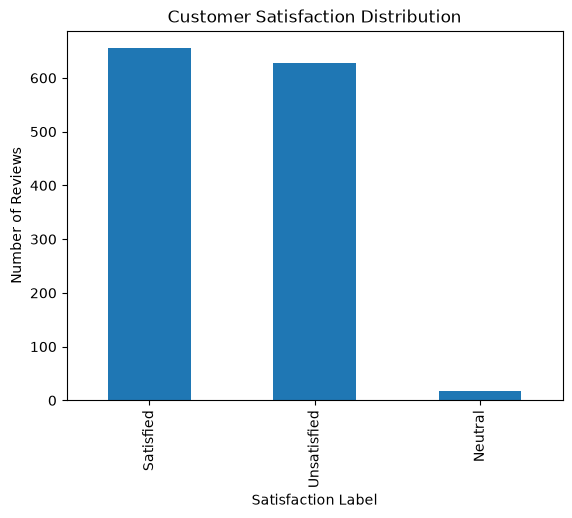

In [14]:
import matplotlib.pyplot as plt

df["satisfaction_label"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Label")
plt.ylabel("Number of Reviews")
plt.show()

In [15]:
from collections import Counter
import re

negative_reviews = df[df["satisfaction_label"] == "Unsatisfied"]

all_text = " ".join(negative_reviews["reviews"].astype(str))

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

common_words = Counter(words)

common_words.most_common(30)

[('the', 4625),
 ('to', 3683),
 ('and', 2707),
 ('i', 2216),
 ('a', 2031),
 ('was', 1845),
 ('in', 1350),
 ('flight', 1249),
 ('of', 1242),
 ('for', 1192),
 ('on', 1101),
 ('my', 929),
 ('they', 927),
 ('we', 899),
 ('with', 895),
 ('that', 892),
 ('not', 820),
 ('ba', 820),
 ('it', 751),
 ('is', 718),
 ('had', 685),
 ('no', 681),
 ('at', 649),
 ('were', 614),
 ('have', 579),
 ('this', 562),
 ('but', 529),
 ('me', 511),
 ('from', 497),
 ('as', 467)]

In [16]:
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word not in stop_words and len(word) > 2
]

common_filtered = Counter(filtered_words)

common_filtered.most_common(30)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('flight', 1249),
 ('service', 439),
 ('london', 404),
 ('british', 308),
 ('airways', 302),
 ('seat', 299),
 ('one', 293),
 ('hours', 291),
 ('class', 285),
 ('time', 272),
 ('staff', 271),
 ('business', 263),
 ('get', 261),
 ('seats', 256),
 ('would', 248),
 ('customer', 239),
 ('food', 238),
 ('told', 226),
 ('heathrow', 225),
 ('airline', 223),
 ('check', 219),
 ('airport', 199),
 ('plane', 195),
 ('even', 190),
 ('back', 189),
 ('could', 187),
 ('crew', 185),
 ('flights', 184),
 ('hour', 180),
 ('cabin', 174)]

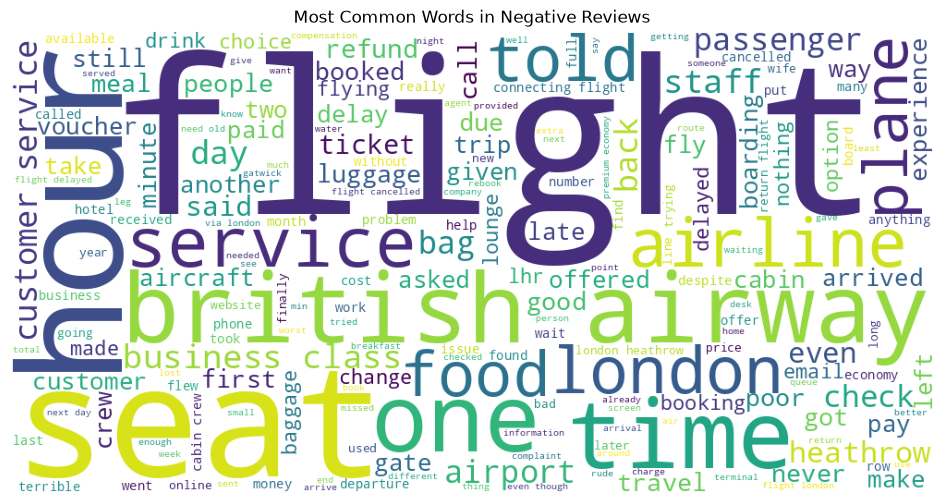

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(" ".join(filtered_words))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Negative Reviews")
plt.show()